In [60]:
import os
import sys

PROJECT_NAME = 'june-2026'

try:

    from google.colab import drive
    drive.mount('/content/drive')

    PROJECT_ROOT = f'D:/Data-Science/Practice/PnT/{PROJECT_NAME}'

    print("Running in Google Colab.")

except:

    PROJECT_ROOT = rf'D:/Data-Science/Practice/PnT/{PROJECT_NAME}'

    print("Running in local environment.")

# Move to project root
os.chdir(PROJECT_ROOT)

print("Current working directory:", os.getcwd())

# Add project root to Python path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

Running in local environment.
Current working directory: D:\Data-Science\Practice\PnT\june-2026


In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [62]:
df = pd.read_csv("./datasets/diabetes.csv")
df.shape

(768, 9)

In [63]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [64]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [66]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [67]:
df["Glucose"] = df["Glucose"].replace(0, np.nan)
df["BMI"] = df["BMI"].replace(0, np.nan)

In [68]:
df.isnull().sum()

Pregnancies                  0
Glucose                      5
BloodPressure                0
SkinThickness                0
Insulin                      0
BMI                         11
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64

In [69]:
df["Glucose"] = df["Glucose"].fillna(df["Glucose"].median())
df["BMI"] = df["BMI"].fillna(df["BMI"].median())

In [70]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [71]:
bmi_glucose = df[["BMI", "Glucose"]]

my_tab = pd.DataFrame()

my_tab["Min"] = bmi_glucose.min()
my_tab["Max"] = bmi_glucose.max()
my_tab

,Min,Max
BMI,18.2,67.1
Glucose,44.0,199.0


In [72]:
df["Age"] = df["Age"].replace(0, np.nan)
df["BloodPressure"] = df["BloodPressure"].replace(0, np.nan)

df["Age"] = df["Age"].fillna(df["Age"].mean())
df["BloodPressure"]= df["BloodPressure"].fillna(df["BloodPressure"].mean())

num_col = df[["BMI", "BloodPressure", "Age"]]

my_tab = pd.DataFrame()

my_tab["Mean"] = num_col.mean()
my_tab["Median"] = num_col.median()
my_tab["Mode"] = num_col.mode().iloc[0]
my_tab["Variance"] = num_col.var()
my_tab["Standard Deviation"] = num_col.std()

my_tab

,Mean,Median,Mode,Variance,Standard Deviation
BMI,32.455208,32.300000,32.3,47.268056,6.875177
BloodPressure,72.405184,72.202592,70.0,146.321591,12.096346
Age,33.240885,29.000000,22.0,138.303046,11.760232


In [73]:
bmi = df["BMI"]
glucose = df["Glucose"]

bmi_vs_glucose = bmi.cov(glucose)
print(bmi_vs_glucose)
if bmi_vs_glucose > 0:
    print("Positive coveriance")
elif bmi_vs_glucose == 0:
    print("No covariance")
else:
    print("Negative covariance")

48.35120599739243
Positive coveriance


In [74]:
age = df["Age"]
bp = df["BloodPressure"]

age_vs_bp = age.cov(bp)
print(age_vs_bp)
if age_vs_bp > 0:
    print("Positive coveriance")
elif age_vs_bp == 0:
    print("No covariance")
else:
    print("Negative covariance")

46.17552306874109
Positive coveriance


In [75]:
#CI = mean +/- z * STD/sqr(n)

sample_mean = df["Glucose"].mean()
sample_std = df["Glucose"].std()
n = len(df)

SE = sample_std/np.sqrt(n)

CI95_lower = sample_mean - (1.96 * SE)
CI95_upper = sample_mean + (1.96 * SE)

print(CI95_lower, CI95_upper)

119.50348981712783 123.80901018287217


In [78]:

df["Outcome"] = df["Outcome"].astype("category")

diabetic = df[df["Outcome"] == 1]["Glucose"]
non_diabetic = df[df["Outcome"] == 0]["Glucose"]

t_statistic, p_value = stats.ttest_ind(diabetic, non_diabetic)

print(t_statistic, p_value)

alpha = .05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

15.673795182294105 3.128719041842255e-48
Reject H0


<Axes: xlabel='Age', ylabel='Count'>

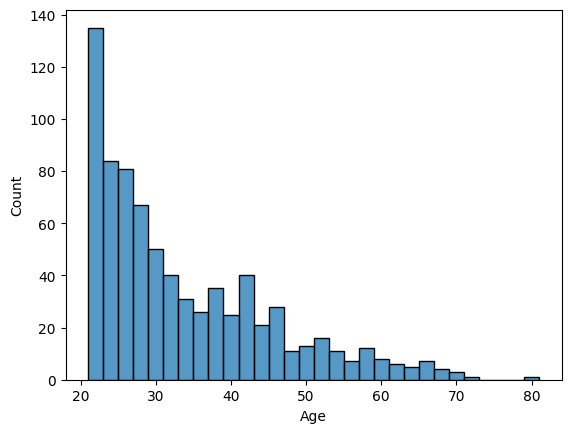

In [79]:
sns.histplot(df["Age"], bins=30)

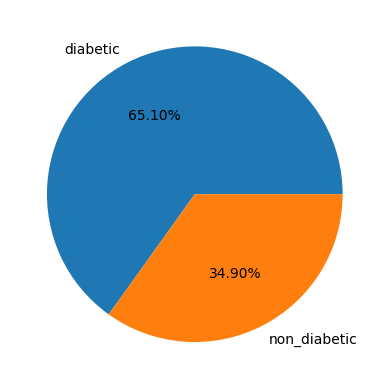

In [83]:
plt.pie(df["Outcome"].value_counts(),
        labels=["diabetic", "non_diabetic"], autopct="%1.2f%%")
plt.show()

<Axes: xlabel='BloodPressure'>

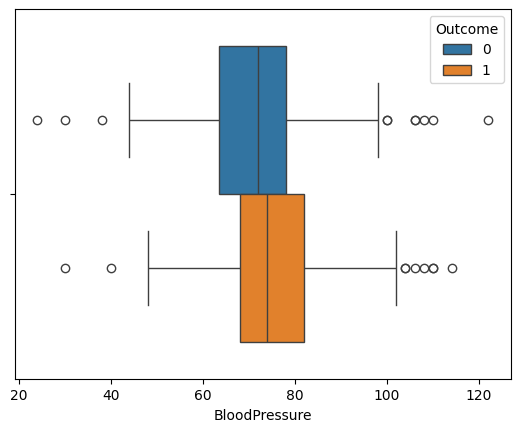

In [85]:
sns.boxplot(x="BloodPressure", hue="Outcome", data=df)

<Axes: xlabel='BloodPressure'>

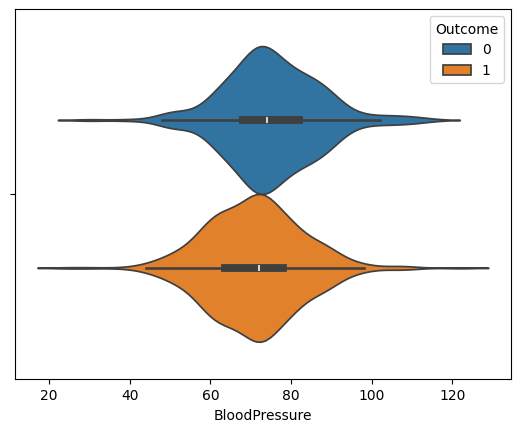

In [86]:
sns.violinplot(x="BloodPressure", hue="Outcome", data=df)

<Axes: xlabel='BMI', ylabel='Glucose'>

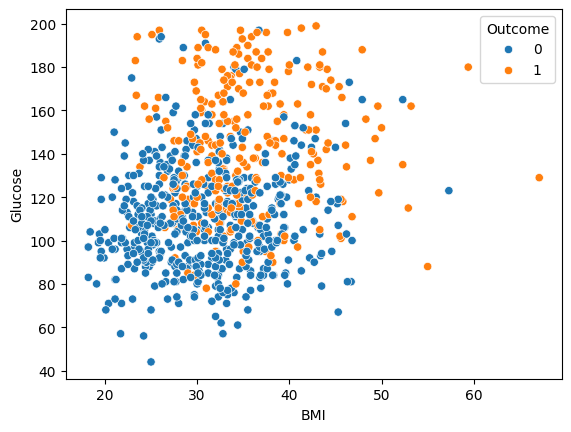

In [88]:
sns.scatterplot(x="BMI", y="Glucose", hue="Outcome", data=df)

<Axes: >

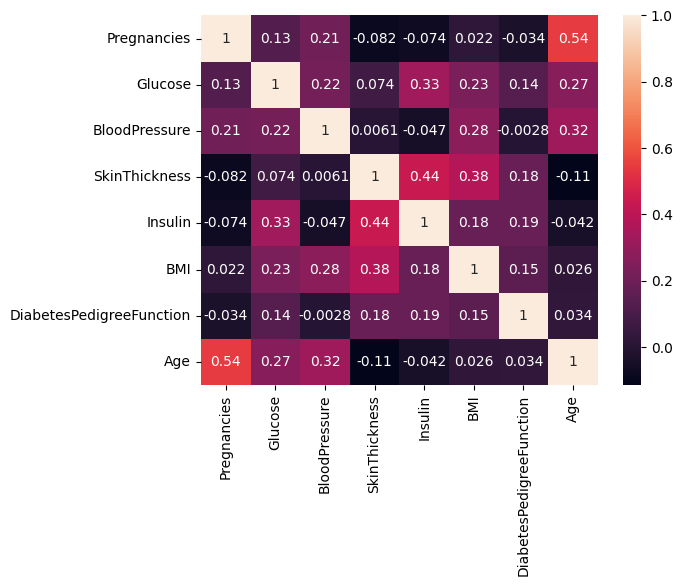

In [96]:
num = df.select_dtypes(np.number)

sns.heatmap(num.corr(),annot=True)